In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('dataset/customer_features.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96095 entries, 0 to 96094
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96095 non-null  str    
 1   frequency           96095 non-null  int64  
 2   monetary            96095 non-null  float64
 3   recency             96095 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 2.9 MB


In [4]:
df.head(5)

,customer_unique_id,frequency,monetary,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,160.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,163.0
2,0000f46a3911fa3c0805444483337064,1,86.22,586.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337.0


#MiSSING VALUE AND DUPLICATE

In [5]:
df.isnull().sum()

customer_unique_id    0
frequency             0
monetary              0
recency               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,frequency,monetary,recency
count,96095.000000,96095.000000,96095.000000
mean,1.034809,166.594226,288.150008
std,0.214385,231.428912,153.413215
min,1.000000,0.000000,0.000000
25%,1.000000,63.120000,164.000000
50%,1.000000,108.000000,269.000000
75%,1.000000,183.530000,397.000000
max,17.000000,13664.080000,773.000000


#EDA (outliers and distribution)

#MONETARY

<Axes: >

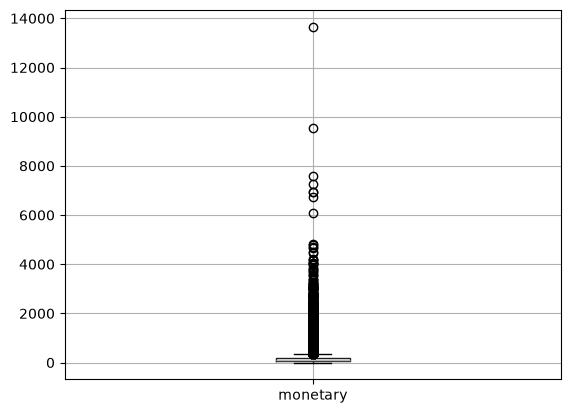

In [8]:
df.boxplot(column='monetary')

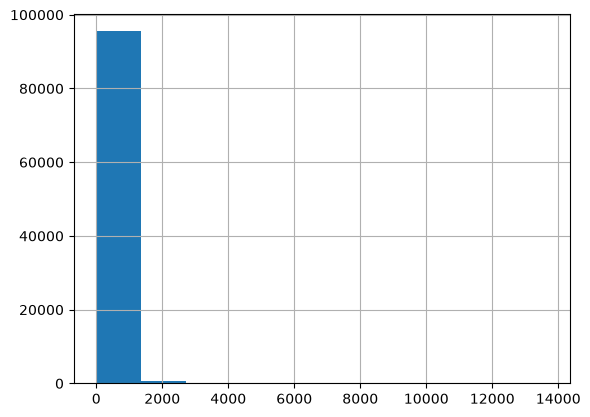

In [9]:
df['monetary'].hist()
plt.show()

#FREQUENCY

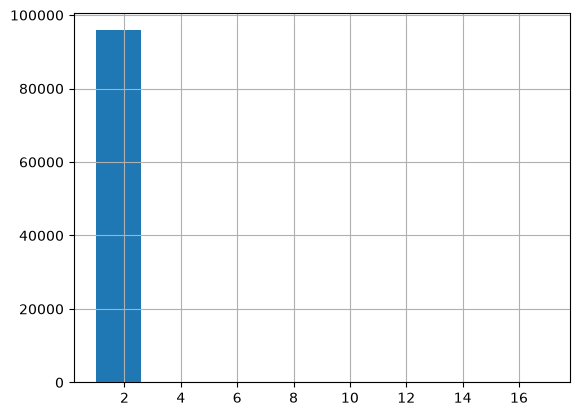

In [10]:
df['frequency'].hist()
plt.show()

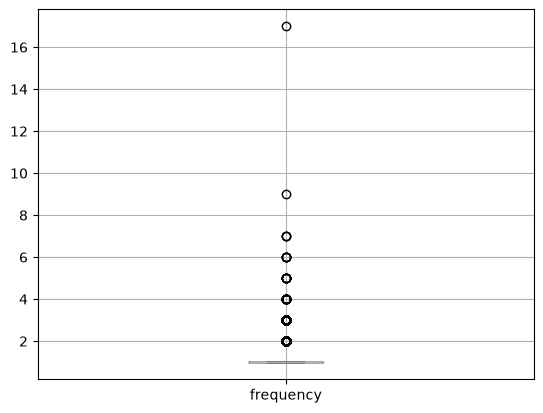

In [11]:
df.boxplot(column='frequency')
plt.show()

#RECENCY

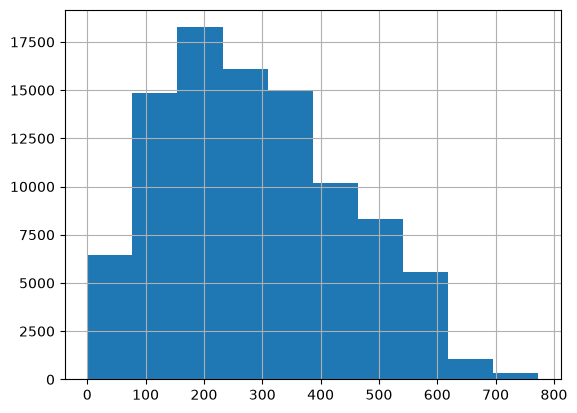

In [12]:
df['recency'].hist()
plt.show()

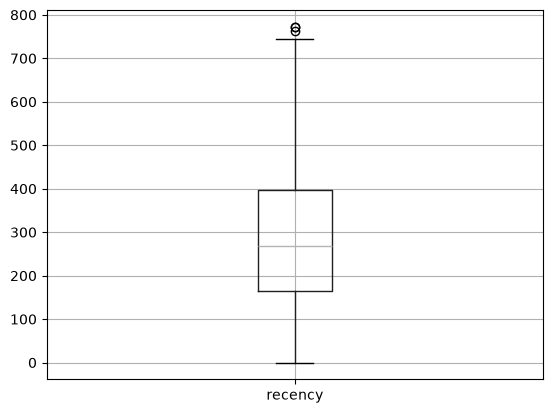

In [13]:
df.boxplot(column='recency')
plt.show()

In [14]:
rfm_log = np.log1p(df[['recency','frequency','monetary']])

#Scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

#Elbow method

In [16]:
from sklearn.cluster import KMeans
wcss = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_) 

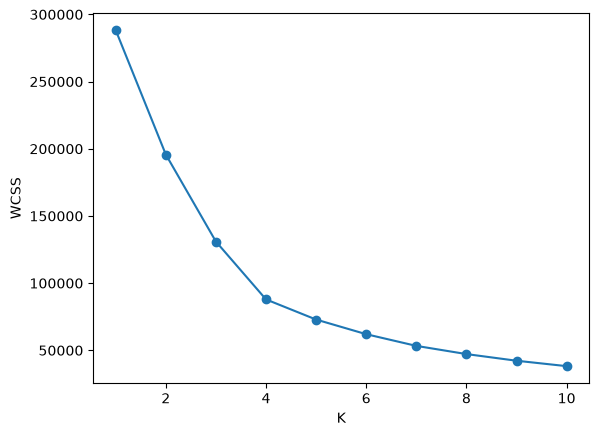

In [17]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.show()

K = 4

#Silhouette Score

In [18]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f'K={k}, Score={score:.3f}')

K=2, Score=0.344
K=3, Score=0.368
K=4, Score=0.376
K=5, Score=0.349
K=6, Score=0.339
K=7, Score=0.352
K=8, Score=0.346
K=9, Score=0.341
K=10, Score=0.342


#K-means

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(rfm_scaled)

In [20]:
df['cluster'] = labels
df.groupby('cluster').mean(numeric_only=True)


,frequency,monetary,recency
cluster,,,
0,1.000000,323.244957,334.532894
1,1.000000,69.930788,367.232582
2,1.000000,122.126845,115.962214
3,2.116116,314.989226,268.621622


In [21]:
cluster_name_map = {
    0: "One-time",
    1: "Churned",
    2: "New customers",
    3: "Loyal customers"
}


df['Segment'] = df['cluster'].map(cluster_name_map)

In [22]:
df.head(5)

,customer_unique_id,frequency,monetary,recency,cluster,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,160.0,2,New customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,163.0,1,Churned
2,0000f46a3911fa3c0805444483337064,1,86.22,586.0,1,Churned
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370.0,1,Churned
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337.0,0,One-time


#Merge features

In [23]:
df_analysis = pd.read_csv('dataset/customer_rank.csv')

In [24]:
analysis = df.merge(df_analysis, on='customer_unique_id', how='left')

In [25]:
analysis.head()

,customer_unique_id,frequency,monetary,recency,cluster,Segment,avg_review_score,total_reviews,avg_delivery_days,total_orders,top_category
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,160.0,2,New customers,5.0,1.0,6.411227,1.0,cama_mesa_banho
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,163.0,1,Churned,4.0,1.0,3.285590,1.0,beleza_saude
2,0000f46a3911fa3c0805444483337064,1,86.22,586.0,1,Churned,3.0,1.0,25.731759,1.0,papelaria
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370.0,1,Churned,4.0,1.0,20.037083,1.0,telefonia
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337.0,0,One-time,5.0,1.0,13.141134,1.0,telefonia


In [26]:
#compare review score (segment)
analysis.groupby('Segment')['avg_review_score'].mean().sort_values()

Segment
One-time           3.937000
Churned            4.080673
Loyal customers    4.116229
New customers      4.254035
Name: avg_review_score, dtype: float64

In [27]:
#statistical test - delivery affect churned?
import scipy.stats as stats

#compare means of churned or not?
churned = analysis[analysis['Segment'] == 'Churned']
others = analysis[analysis['Segment'] != 'Churned']
print(churned['avg_delivery_days'].mean())
print(others['avg_delivery_days'].mean())

t_stat, p = stats.ttest_ind(
    churned['avg_delivery_days'].dropna(),
    others['avg_delivery_days'].dropna(),
    equal_var=False
)
print(f'p:{p:.9f}')
#churn significantly

#churned reason base on review_score and delivery time
# Xác định ngưỡng "giao chậm" dựa theo phân phối thực tế
delivery_threshold = churned['avg_delivery_days'].quantile(0.75)
print(f"Ngưỡng giao chậm (percentile 75): {delivery_threshold:.1f} ngày")

def churn_reason(row):
    score = row['avg_review_score']
    delivery = row['avg_delivery_days']

    bad_review = score <= 2
    good_review = score >= 4
    slow_delivery = delivery > delivery_threshold

    if bad_review and slow_delivery:
        return 'bad experience - slow delivery'
    elif bad_review and not slow_delivery:
        return 'bad experience - other'
    elif good_review and slow_delivery:
        return 'slow delivery despite good review'
    elif good_review and not slow_delivery:
        return 'natural churn'
    else:
        # score == 3
        if slow_delivery:
            return 'unclear - slow delivery'
        else:
            return 'unclear'

churned['churn_reason'] = churned.apply(churn_reason, axis=1)

print(churned['churn_reason'].value_counts())
print(churned['churn_reason'].value_counts(normalize=True).mul(100).round(1))


12.950904676199066
12.237522733574217
p:0.000000000
Ngưỡng giao chậm (percentile 75): 16.1 ngày
churn_reason
natural churn                        24031
slow delivery despite good review     5832
bad experience - other                3088
unclear                               2653
bad experience - slow delivery        2477
unclear - slow delivery               1118
Name: count, dtype: int64
churn_reason
natural churn                        61.3
slow delivery despite good review    14.9
bad experience - other                7.9
unclear                               6.8
bad experience - slow delivery        6.3
unclear - slow delivery               2.9
Name: proportion, dtype: float64


In [28]:
churned.head(5)

,customer_unique_id,frequency,monetary,recency,cluster,Segment,avg_review_score,total_reviews,avg_delivery_days,total_orders,top_category,churn_reason
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,163.0,1,Churned,4.0,1.0,3.285590,1.0,beleza_saude,natural churn
2,0000f46a3911fa3c0805444483337064,1,86.22,586.0,1,Churned,3.0,1.0,25.731759,1.0,papelaria,unclear - slow delivery
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370.0,1,Churned,4.0,1.0,20.037083,1.0,telefonia,slow delivery despite good review
6,00050ab1314c0e55a6ca13cf7181fecf,1,35.38,180.0,1,Churned,4.0,1.0,6.966389,1.0,telefonia,natural churn
10,0006fdc98a402fceb4eb0ee528f6a8d4,1,29.00,456.0,1,Churned,3.0,1.0,16.388646,1.0,cama_mesa_banho,unclear - slow delivery


In [29]:
analysis = analysis.merge(churned[['customer_unique_id', 'churn_reason']],on='customer_unique_id',how='left')

In [30]:
#caculate average order value
analysis['aov'] = analysis['monetary'] / analysis['frequency']

In [31]:
#CLV
analysis['clv'] = analysis['monetary']

In [32]:
# % revenue based on segment
revenue_by_segment = analysis.groupby('Segment').agg(
    total_revenue = ('monetary', 'sum'),
    customer_cnt  = ('monetary', 'count')
).round(2)

revenue_by_segment['revenue_pct'] = (
    revenue_by_segment['total_revenue'] / 
    revenue_by_segment['total_revenue'].sum() * 100
).round(1)

revenue_by_segment.sort_values('revenue_pct', ascending=False)

,total_revenue,customer_cnt,revenue_pct
Segment,,,
One-time,9227350.54,28546,57.6
New customers,3096281.90,25353,19.3
Churned,2741216.97,39199,17.1
Loyal customers,944022.71,2997,5.9


In [33]:
analysis.groupby('Segment')['aov'].mean().sort_values(ascending=False)

Segment
One-time           323.244957
Loyal customers    148.500545
New customers      122.126845
Churned             69.930788
Name: aov, dtype: float64

In [34]:
analysis.groupby('Segment').agg(
    count        = ('monetary', 'count'),
    avg_monetary = ('monetary', 'mean'),
    total        = ('monetary', 'sum')
).round(2)

,count,avg_monetary,total
Segment,,,
Churned,39199,69.93,2741216.97
Loyal customers,2997,314.99,944022.71
New customers,25353,122.13,3096281.90
One-time,28546,323.24,9227350.54


In [35]:
analysis[analysis['Segment'] == 'One-time'] \
    .groupby('top_category')['avg_review_score'] \
    .mean().sort_values().head(10)

top_category
dvds_blu_ray                     2.833333
bebidas                          2.958333
cine_foto                        3.125000
fashion_roupa_masculina          3.384615
fashion_roupa_feminina           3.500000
pc_gamer                         3.500000
moveis_escritorio                3.554396
telefonia_fixa                   3.607143
casa_conforto                    3.664336
construcao_ferramentas_jardim    3.666667
Name: avg_review_score, dtype: float64

In [42]:
analysis['value_tier'] = pd.qcut(
    analysis['monetary'],
    q=3,
    labels=['low', 'mid', 'high']
)

one_time_mask = analysis['Segment'] == 'One-time'
analysis.loc[one_time_mask, 'convert_potential'] = (
    analysis.loc[one_time_mask, 'monetary'] * 0.10
)
expected_revenue = analysis.loc[one_time_mask, 'convert_potential'].sum()
print(expected_revenue)

922735.054


In [37]:
analysis.head()

,customer_unique_id,frequency,monetary,recency,cluster,Segment,avg_review_score,total_reviews,avg_delivery_days,total_orders,top_category,churn_reason,aov,clv,value_tier,convert_potential
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,160.0,2,New customers,5.0,1.0,6.411227,1.0,cama_mesa_banho,NaN,141.90,141.90,mid,NaN
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,163.0,1,Churned,4.0,1.0,3.285590,1.0,beleza_saude,natural churn,27.19,27.19,low,NaN
2,0000f46a3911fa3c0805444483337064,1,86.22,586.0,1,Churned,3.0,1.0,25.731759,1.0,papelaria,unclear - slow delivery,86.22,86.22,mid,NaN
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370.0,1,Churned,4.0,1.0,20.037083,1.0,telefonia,slow delivery despite good review,43.62,43.62,low,NaN
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337.0,0,One-time,5.0,1.0,13.141134,1.0,telefonia,NaN,196.89,196.89,high,19.689


In [38]:
analysis.to_csv('analysis.csv', index=False)